#  **Dogecoin Price Prediction using SARIMAX**

#### **1. Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

This block imports the libraries required for data analysis, visualization, and machine learning.

*   **Pandas** → Data manipulation and analysis.
*   **NumPy** → Numerical operations.
*   **Matplotlib** → Plotting graphs.
*   **Seaborn** → Advanced data visualization.
*   **RandomForestRegressor** → Machine learning model (imported but not used later).


**Result**: Libraries are loaded successfully and ready for use.


---



#### **2. Load Dataset**

In [ ]:
data = pd.read_csv("/content/DOGE-USD.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


The Dogecoin historical price dataset is loaded from a CSV file. head() displays the first five records.


---



#### **3. Check Dataset Size**

In [ ]:
data.shape

(1761, 7)

Returns the number of rows and columns.
*  1761 observations (days)
*  7 features


---



#### **4. Correlation Analysis**

In [ ]:
data.corr(numeric_only=True)

# This code is modified by Susobhan Akhuli

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


Calculates correlation among numerical variables.

**Correlation values range from:**

*  +1 → Strong positive relationship
*  0 → No relationship
*  -1 → Strong negative relationship

**Key Observations:**

1.   **High vs Close**	0.995
2.   **Low vs Close**	0.994
2.   **Open vs Close**	0.992

This shows price-related variables are highly correlated.


---




#### **5. Correlation Heatmap**

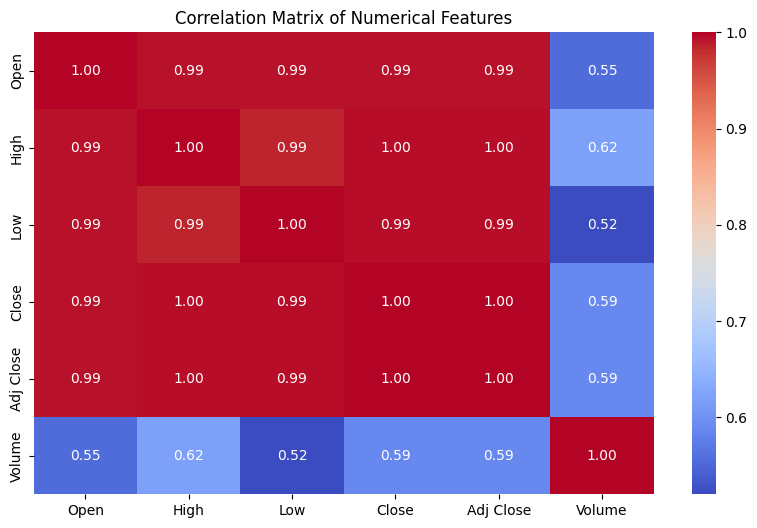

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Visualizes correlations using a heatmap.

**Result**
*  **Dark red** = strong positive correlation
*  **Blue** = weak correlation

**Insight**: Open, High, Low, and Close prices move together strongly.


---



#### **6. Convert Date Column & Missing Value Check**

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data = data.dropna()
data.isnull().any()

,0
Open,False
High,False
Low,False
Close,False
Adj Close,False
Volume,False


Converts Date into datetime format and sets it as the index. Removes missing values and checks whether any remain.

**Why?** Time-series models require a date index.


---



#### **7. Dataset Preview**

In [ ]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


#### **8. Count Missing Values**

In [ ]:
data.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
data = data.dropna()

#### **9. Statistical Summary**

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


#### **10. Closing Price Trend**

Text(0.5, 1.0, 'Date vs Close of 2021')

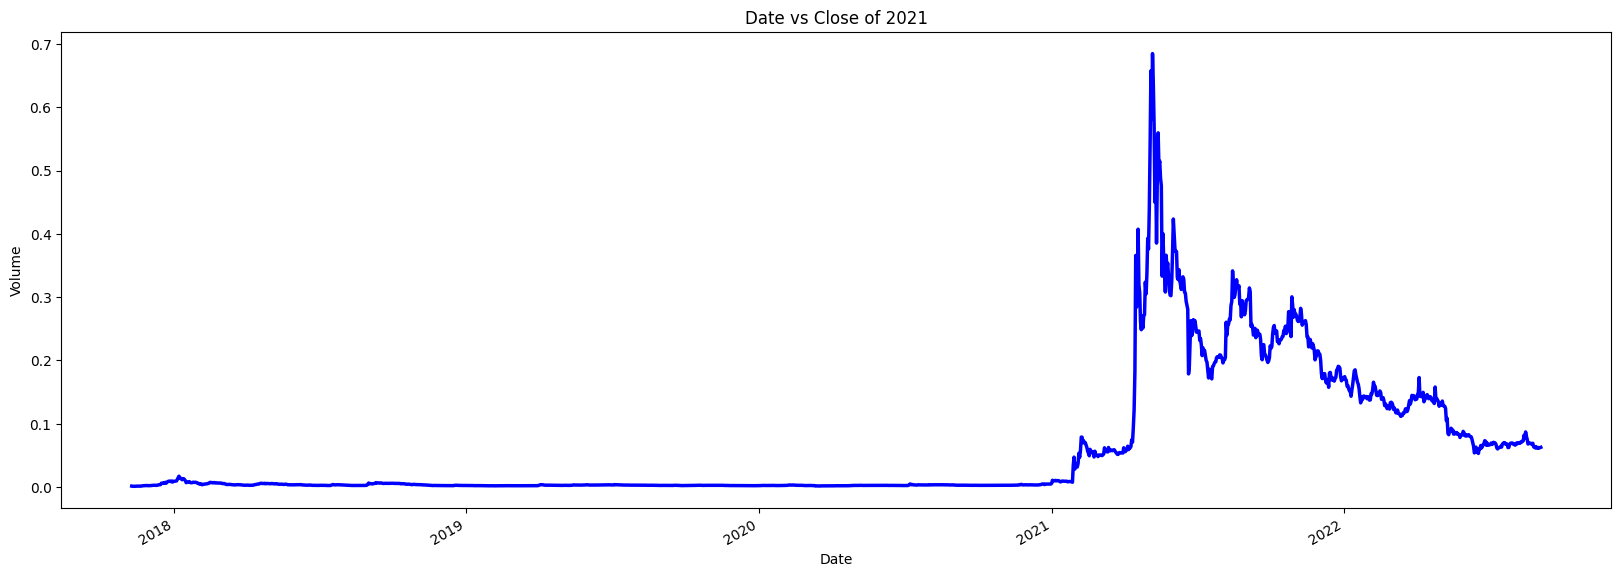

In [ ]:
plt.figure(figsize=(20, 7))
x = data.groupby('Date')['Close'].mean()
x.plot(linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title("Date vs Close of 2021")

Plots Dogecoin closing prices over time.

**Result**: Shows long-term market trends and volatility.

**Insight**: Major spikes indicate periods of increased investor activity.


---



#### **11. High, Low and Close Prices**

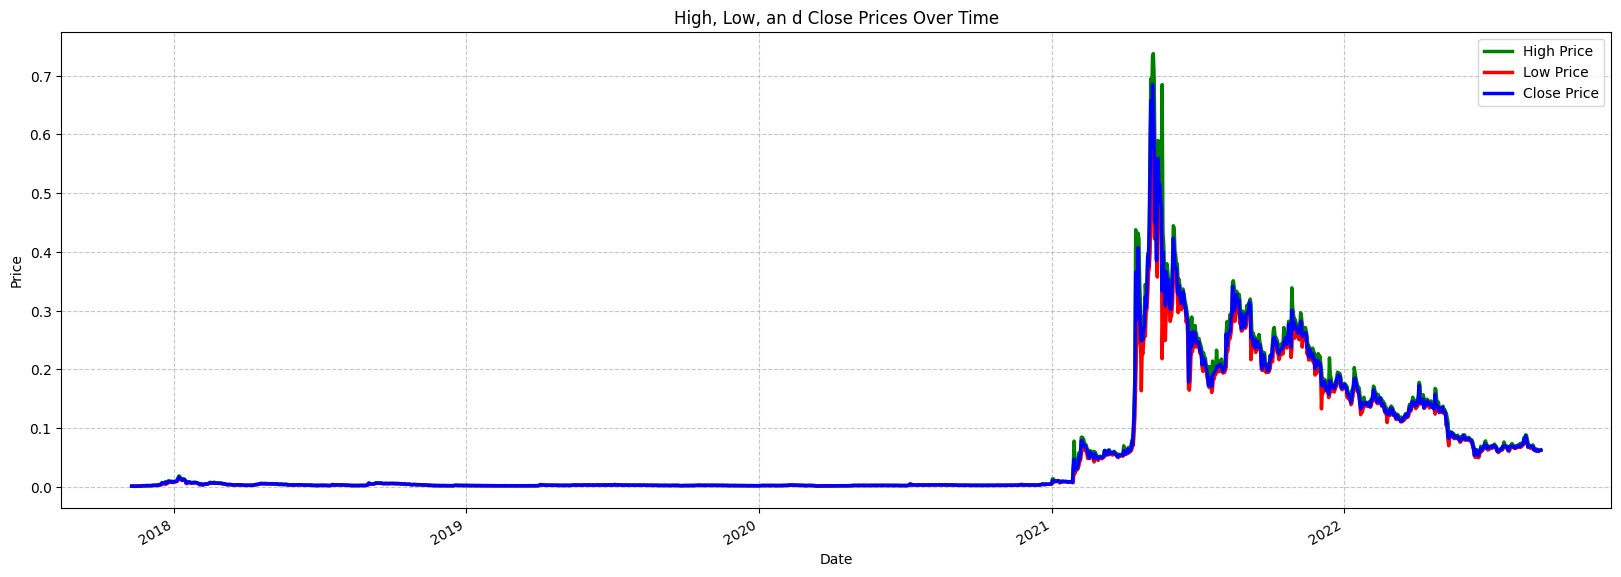

In [ ]:
plt.figure(figsize=(20, 7))

data['High'].plot(label='High Price', linewidth=2.5, color='green')
data['Low'].plot(label='Low Price', linewidth=2.5, color='red')
data['Close'].plot(label='Close Price', linewidth=2.5, color='blue')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title("High, Low, an d Close Prices Over Time")
plt.legend()
plt.grid(True, linestyle='--',alpha=.7)
plt.show()

**Compares**:

*  Highest daily price
*  Lowest daily price
*  Closing price

**Result**: Shows how Dogecoin fluctuates daily.


---



#### **12. Feature Engineering**

In [ ]:
data["gap"] = (data["High"] - data["Low"]) * data["Volume"]
data["y"] = data["High"] / data["Volume"]
data["z"] = data["Low"] / data["Volume"]
data["a"] = data["High"] / data["Low"]
data["b"] = (data["High"] / data["Low"]) * data["Volume"]
abs(data.corr()["Close"].sort_values(ascending=False))

,Close
Close,1.000000
Adj Close,1.000000
High,0.995104
Low,0.994575
Open,0.992514
Volume,0.588678
b,0.456479
gap,0.383333
a,0.172057
z,0.063251


#### **13. Feature Importance using Correlation**

In [ ]:
data = data[["Close", "Volume", "gap", "a", "b"]]
data.head()

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


High and Low prices are strongest predictors.


---



#### **14. Create Train-Test Split**

In [ ]:
df2 = data.tail(30)
train = df2[:11]
test = df2[-19:]

print(train.shape, test.shape)

(11, 5) (19, 5)


Uses the most recent 30 observations.

**Split into:**

*  **Training** = 11 days
*  **Testing** = 19 days


---



In [ ]:
df2.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-05,0.069765,336216727.0,9.619161e+05,1.042539,3.505190e+08
2022-08-06,0.068674,277979112.0,6.707636e+05,1.035182,2.877590e+08
2022-08-07,0.068940,204862521.0,4.408641e+05,1.031765,2.113700e+08
2022-08-08,0.070055,399183407.0,1.251440e+06,1.045486,4.173405e+08
2022-08-09,0.069125,611327142.0,3.315838e+06,1.079226,6.597604e+08


In [ ]:
train.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-05,0.069765,336216727.0,9.619161e+05,1.042539,3.505190e+08
2022-08-06,0.068674,277979112.0,6.707636e+05,1.035182,2.877590e+08
2022-08-07,0.068940,204862521.0,4.408641e+05,1.031765,2.113700e+08
2022-08-08,0.070055,399183407.0,1.251440e+06,1.045486,4.173405e+08
2022-08-09,0.069125,611327142.0,3.315838e+06,1.079226,6.597604e+08


In [ ]:
test.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-16,0.086964,1.947378e+09,2.384564e+07,1.160287,2.259518e+09
2022-08-17,0.080154,9.962729e+08,8.155490e+06,1.102418,1.098310e+09
2022-08-18,0.075079,6.213942e+08,4.410656e+06,1.094654,6.802115e+08
2022-08-19,0.067939,9.655435e+08,7.383511e+06,1.113229,1.074871e+09
2022-08-20,0.069540,5.372994e+08,1.646285e+06,1.045127,5.615462e+08


#### **15. Build SARIMAX Model**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(endog=train["Volume"], exog=train.drop(
    "Volume", axis=1), order=(2, 1, 1))
results = model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 Volume   No. Observations:                   11
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -148.591
Date:                Mon, 15 Jun 2026   AIC                            313.182
Time:                        16:24:33   BIC                            315.603
Sample:                    08-05-2022   HQIC                           310.526
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Close       4.056e+08   1.63e-09   2.49e+17      0.000    4.06e+08    4.06e+08
gap          -14.1708      0.291    -48.696      0.000     -14.741     -13.600
a          -3.691e+07   4.26e-07  -8.66e+13      0.0

SARIMAX is a time-series forecasting model.

**Parameters**:
*  p=2 → autoregressive terms
*  d=1 → differencing
*  q=1 → moving average term
*  Exogenous Variables

**Uses**:

*  Close
*  gap
*  a
*  b

to help forecast Volume.


---



In [ ]:
start = 11
end = 29
predictions = results.predict(
    start=start,
    end=end,
    exog=test.drop("Close", axis=1))
predictions

,predicted_mean
2022-08-16,0.097293
2022-08-17,0.083717
2022-08-18,0.075957
2022-08-19,0.069575
2022-08-20,0.071583
2022-08-21,0.072099
2022-08-22,0.071244
2022-08-23,0.072458
2022-08-24,0.072406
2022-08-25,0.071893


#### **16. Generate Predictions**

In [ ]:
predictions_direct = results.predict(
    start=11,
    end=29,
    exog=test.drop("Close", axis=1))
predictions_direct

,predicted_mean
2022-08-16,0.097293
2022-08-17,0.083717
2022-08-18,0.075957
2022-08-19,0.069575
2022-08-20,0.071583
2022-08-21,0.072099
2022-08-22,0.071244
2022-08-23,0.072458
2022-08-24,0.072406
2022-08-25,0.071893


#### **17. Plot Actual vs Predicted Values**

<Axes: xlabel='Date'>

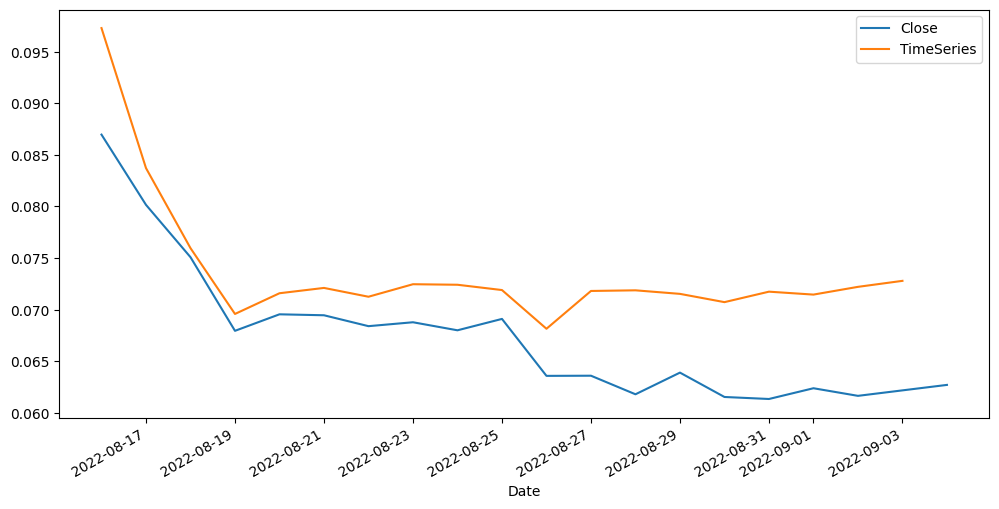

In [ ]:
test["Close"].plot(legend=True, figsize=(12, 6))
predictions.plot(label='TimeSeries', legend=True)

#### **CONCLUSION**
This project analyzes historical Dogecoin price data and applies a SARIMAX time-series forecasting model to predict future cryptocurrency prices. Feature engineering techniques were used to create volatility and volume-based indicators. Correlation analysis helped identify the most influential variables, and SARIMAX was trained using these features to generate forecasts. The final visualization compares actual and predicted values to evaluate model performance.


---


⚠️ Model is trained on only 11 records and tested on 19 records, which is very small for a forecasting model. For a stronger project, increase the training data size and evaluate using metrics such as MAE, RMSE, and R².

---

